A pasta Preditiva_Chikungunya já existe. Os arquivos serão salvos nela.


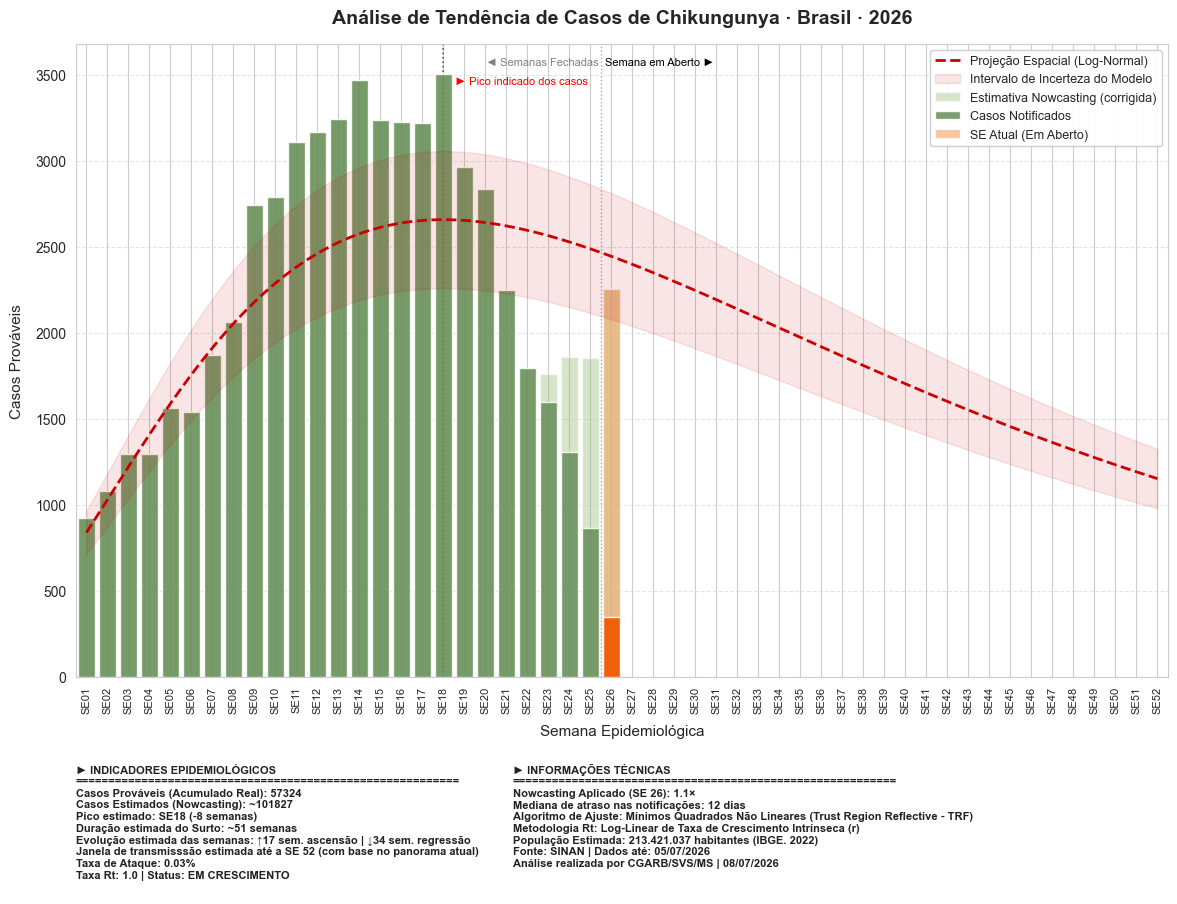

In [ ]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.stats import linregress, lognorm
from datetime import datetime
import os

# =========================================== #

# Dicionário de Variáveis para filtro
nome_municipio = 'XXXXXX'          # NÃO USAR ACENTO
mun_sinan = 000000                 # Inserir código IBGE do município
populacao = 000000                 # População Brasil: 213_421_037
data_dados = 'dd/mm/aaaa'          # 

# =========================================== #

# Carregar base de dados
file_path = 'chik_provaveis.xlsx'
df_provaveis = pd.read_excel(file_path)

# Filtrar para o município de interesse 
df_provaveis = df_provaveis[df_provaveis['ID_MN_RESI'] == mun_sinan].copy()                                            # Desativar o filtro para analisar dados do Brasil
provaveis = len(df_provaveis)

# Criar pasta para salvar os arquivos
nome_pasta = f'Tendencia_Chikungunya'
local_salvar = os.getcwd()
local_pasta = os.path.join(local_salvar, nome_pasta)

if not os.path.exists(local_pasta):
    os.makedirs(local_pasta)
    print(f"Pasta {nome_pasta} criada!")
else:
    print(f"A pasta {nome_pasta} já existe. Os arquivos serão salvos nela.")

# Valoração dos dias de atraso da notificação no SINAN
df_atraso = df_provaveis.copy()

# 1. Transformar as colunas no formato oficial de data (datetime)
df_atraso['DT_SIN_PRI'] = pd.to_datetime(df_atraso['DT_SIN_PRI'], errors='coerce')
df_atraso['DT_DIGITA'] = pd.to_datetime(df_atraso['DT_DIGITA'], errors='coerce')

# 2. Calcular a diferença de dias
df_atraso['Atraso_Digitacao_Dias'] = (df_atraso['DT_DIGITA'] - df_atraso['DT_SIN_PRI']).dt.days

# Filtrar e retirar dias negativos (erro de digitação)
df_validos = df_atraso[df_atraso['Atraso_Digitacao_Dias'] >= 0]

# 3. Ver os resultados
mediana_atraso = df_validos['Atraso_Digitacao_Dias'].median()
max_atraso = df_validos['Atraso_Digitacao_Dias'].max()
min_atraso = df_validos['Atraso_Digitacao_Dias'].min()

# =========================================== #

# Cálculo da taxa de ataque
casos_mun = provaveis
taxa_ataque = (casos_mun / populacao) * 100

# =========================================== #

# 1 CARREGAMENTO, LIMPEZA E TRATAMENTO DA SÉRIE TEMPORAL
POPULACAO = populacao
TAXA_ATAQUE_HISTORICA = 0.5
data_analise = datetime.now().strftime("%d/%m/%Y")

try:
    df_analise = df_provaveis.copy()
except Exception as e:
    raise FileNotFoundError(f"Erro ao carregar o arquivo excel: {e}")

# Garantir que os valores da coluna SE sejam numéricos
df_analise['SE'] = pd.to_numeric(df_analise['SE'], errors='coerce')
df_analise = df_analise.dropna(subset=['SE'])

if 'Semana Epidemiológica' in df_analise.columns:
    df_analise = df_analise[~df_analise['Semana Epidemiológica'].str.contains('53ª', na=False)]

contagem_bruta = df_analise['SE'].value_counts()     # Garantir todas as semanas no DataFrame
df_previsao = contagem_bruta.reindex(range(1, 53), fill_value=0).reset_index()     # Forçar todas as semanas a aparecerem 
df_previsao.columns = ['num_semana', 'casos_brutos']
df_previsao = df_previsao.sort_values(by='num_semana').reset_index(drop=True)
df_previsao['tempo'] = df_previsao['num_semana']

ultima_semana_com_dados = df_analise['SE'].max()     # Identificação dinâmica das semanas preenchidas no arquivo
df_previsao = df_previsao[df_previsao['num_semana'] <= ultima_semana_com_dados].copy()   # Filtrar até a última semana com dados

N_SEMANAS = len(df_previsao)
SE_ATUAL  = df_previsao['num_semana'].iloc[-1]  
SE_FECHADAS = N_SEMANAS - 1  

# 2 FUNÇÕES AUXILIARES E MODELAGEM MATEMÁTICA PARA PROJEÇÃO EPIDEMIOLÓGICA

def modelo_lognormal(x, amplitude, s, loc, scale):
    
    """
    Método escolhido: Distribuição Log-Normal (captura a assimetria real
    da curva epidêmica em um surto.
    """
    
    # Evita divisões por zero ou valores negativos no domínio log
    x_ajustado = np.maximum(x - loc, 1e-5)
    return amplitude * lognorm.pdf(x_ajustado, s, scale=scale)

def obter_dia_atual_dados(df):
    
    """
    Em vez de usar cegamente o relógio do sistema, assume o dia com base 
    na última semana com dados ou usa um fallback seguro.
    """
    
    # Mantido o fallback original ajustado caso precise rodar em tempo real
    dia_da_semana = datetime.now().weekday()
    dia_atual = (dia_da_semana + 2) % 7
    return 7 if dia_atual == 0 else dia_atual

# 3 NOWCASTING — CORREÇÃO DE ATRASO DE NOTIFICAÇÃO
MEDIA_ATRASO_DIAS = mediana_atraso
DIA_ATUAL_NA_SEMANA = obter_dia_atual_dados(df_previsao)

df_previsao['casos_corrigidos'] = df_previsao['casos_brutos'].astype(float)

for k in range(1, 5): 
    idx = len(df_previsao) - k
    if 0 <= idx < len(df_previsao):
        dias_decorridos = max(DIA_ATUAL_NA_SEMANA / 2.0, 0.5) if k == 1 else (k - 1) * 7 + DIA_ATUAL_NA_SEMANA - 3.5
        
        # AJUSTE 1: Reduzi o piso da proporção de 0.15 para 0.05. 
        # Isso permite que a matemática pura calcule fatores de até 20x (1 / 0.05) se os dias decorridos forem mínimos.
        proporcao = max(1.0 - np.exp(-dias_decorridos / MEDIA_ATRASO_DIAS), 0.05)
        
        # AJUSTE 2: Teto dinâmico baseado na mediana de atraso do município específico.
        # Mantemos os valores antigos (4.5, 2.5, etc.) apenas como piso de segurança para municípios muito ágeis.
        if k == 1:
            teto_seguranca = max(4.5, MEDIA_ATRASO_DIAS / 1.5)  # Ex: Atraso de 15 dias libera multiplicador de até 10x
        elif k == 2:
            teto_seguranca = max(2.5, MEDIA_ATRASO_DIAS / 3.0)  # Ex: Atraso de 15 dias libera multiplicador de até 5x
        elif k == 3:
            teto_seguranca = max(1.3, MEDIA_ATRASO_DIAS / 6.0)
        else:
            teto_seguranca = 1.1

        # O fator agora é o cálculo biológico real, limitado pelo teto flexível da cidade
        fator_nowcasting = min(1.0 / proporcao, teto_seguranca)
        
        df_previsao.loc[idx, 'casos_corrigidos'] = df_previsao.loc[idx, 'casos_brutos'] * fator_nowcasting

# 4 ESTIMATIVA DE REPRODUÇÃO (Rt) — CRESCIMENTO EXPONENCIAL

INTERVALO_SERIAL_SEMANAS = 1.0   
JANELA_RT = min(4, SE_FECHADAS)  

y_janela = df_previsao['casos_corrigidos'].values[-(JANELA_RT + 1):-1] 
x_janela = np.arange(len(y_janela), dtype=float)

# Proteção matemática contra log de zero
y_log = np.log(np.maximum(y_janela, 0.1))
slope, intercept, r_value, p_value, std_err = linregress(x_janela, y_log)
taxa_crescimento_r = slope
Rt = np.exp(taxa_crescimento_r * INTERVALO_SERIAL_SEMANAS)

razao_crescimento = (df_previsao['casos_corrigidos'].iloc[-2] /
                     df_previsao['casos_corrigidos'].iloc[-3]
                     if df_previsao['casos_corrigidos'].iloc[-3] > 0 else 1.0)

# 5 PROJEÇÃO EPIDEMIOLÓGICA ASSIMÉTRICA (LOG-NORMAL)

indice_pico_bruto = df_previsao['casos_brutos'].idxmax()
se_pico_observado = float(df_previsao['tempo'].iloc[indice_pico_bruto])
valor_pico_observado = df_previsao['casos_brutos'].max()

casos_acumulados_corrigidos = df_previsao['casos_corrigidos'].sum()
taxa_ataque_notificada = taxa_ataque

TAXA_ATAQUE_MODELO = max(TAXA_ATAQUE_HISTORICA, taxa_ataque_notificada * 2.0)
CASOS_ESPERADOS_TOTAL = (TAXA_ATAQUE_MODELO / 100) * POPULACAO

y_real = df_previsao['casos_corrigidos'].values
x_fit = df_previsao['tempo'].values

y_fit_suavizado = df_previsao['casos_corrigidos'].rolling(window=3, min_periods=1, center=True).mean().values

# Pesos para priorizar as últimas semanas (sigma)
pesos = np.ones(len(y_fit_suavizado))
if len(y_fit_suavizado) >= 4:
    pesos[-4:] = [1.2, 1.5, 1.8, 2.0]
sigma_pesos = 1.0 / pesos

# LIMITES (BOUNDS) PARA EPIDEMIA DE CHIKUNGUNYA
area_estimada = df_previsao['casos_corrigidos'].sum()
se_max_dados = x_fit[-1]

limite_biologico_absoluto = POPULACAO * 0.50 
amp_min = area_estimada * 0.5
amp_max_calc = min(limite_biologico_absoluto, CASOS_ESPERADOS_TOTAL * 3.0)
amp_max = max(amp_min * 1.5, amp_max_calc) 

# AJUSTE 2: Função que "trava" matematicamente o pico na semana observada
def modelo_lognormal_ancorado(x, amplitude, s, loc):
    x_ajustado = np.maximum(x - loc, 1e-5)
    # O modo (pico) da log-normal é: loc + scale * exp(-s^2). 
    # Aqui isolamos o 'scale' para que o pico caia exatamente onde queremos:
    scale_forcado = (se_pico_observado - loc) * np.exp(s**2)
    return amplitude * lognorm.pdf(x_ajustado, s, scale=scale_forcado)

# Novos limites e P0 sem fornecer o scale (ele será deduzido pela ancoragem).
# O parâmetro 'loc' é protegido para NUNCA ultrapassar a semana de pico.
bounds_ancorado = (
    [amp_min, 0.2, -10.0], 
    [amp_max, 2.0, float(se_pico_observado) - 0.1] 
)

# Chute Inicial (P0) Blindado com np.clip
amp_p0_raw = area_estimada * 1.5 
pico_esperado_chute = se_pico_observado
scale_p0_raw = (pico_esperado_chute - 0.0) * np.exp(0.5**2)

amp_p0_raw = area_estimada * 1.5 
p0_ancorado = [
    np.clip(amp_p0_raw, amp_min * 1.01, amp_max * 0.99),
    np.clip(0.5, 0.202, 1.98),
    np.clip(0.0, -9.9, float(se_pico_observado) - 1.0)
]

ajuste_ok = False

try:
    popt, pcov = curve_fit(
        modelo_lognormal_ancorado, x_fit, y_fit_suavizado,
        p0=p0_ancorado, 
        bounds=bounds_ancorado, 
        sigma=sigma_pesos,       
        absolute_sigma=False,    
        maxfev=200000            
    )
    amplitude_fit, s_fit, loc_fit = popt
    perr = np.sqrt(np.diag(pcov))
    
    # AJUSTE 3: Recupera o scale final otimizado para que a projeção inteira funcione
    scale_fit = (se_pico_observado - loc_fit) * np.exp(s_fit**2)
    
    # Projeção no horizonte completo de semanas do ano
    x_proj = np.linspace(1, 52, 500)
    
    # Voltamos a usar sua função original para desenhar a curva final:
    y_proj = modelo_lognormal(x_proj, amplitude_fit, s_fit, loc_fit, scale_fit)
    
    # Cálculo do ponto de pico projetado
    idx_pico_proj = np.argmax(y_proj)
    x0_fit = x_proj[idx_pico_proj]
    casos_pico_estimado = y_proj[idx_pico_proj]
    distancia_pico = x0_fit - SE_ATUAL
    
    # Intervalos de incerteza 
    fator_erro_amp = min(perr[0], amplitude_fit * 0.15)
    y_proj_sup = modelo_lognormal(x_proj, amplitude_fit + fator_erro_amp, s_fit, loc_fit, scale_fit)
    y_proj_inf = modelo_lognormal(x_proj, max(amplitude_fit - fator_erro_amp, 0), s_fit, loc_fit, scale_fit)

    # Integração robusta
    if hasattr(np, 'trapezoid'):
        casos_totais_proj = np.trapezoid(y_proj, x_proj)
    else:
        casos_totais_proj = np.trapz(y_proj, x_proj)

    # Métricas temporais (limiar de 5%)
    limiar_atividade = casos_pico_estimado * 0.05
    semanas_ativas = x_proj[y_proj >= limiar_atividade]
    
    if len(semanas_ativas) > 0:
        se_inicio_surto = semanas_ativas[0]
        se_fim_surto = semanas_ativas[-1]
        duracao_total = se_fim_surto - se_inicio_surto
        duracao_subida = x0_fit - se_inicio_surto
        duracao_queda = se_fim_surto - x0_fit
    else:
        se_inicio_surto, se_fim_surto, duracao_total, duracao_subida, duracao_queda = 0, 0, 0, 0, 0
    
    ajuste_ok = True
except RuntimeError:    
    ajuste_ok = False
except Exception as e:
    print(f"Aviso: Erro inesperado na projeção matemática: {e}")       
    ajuste_ok = False

# 6 CLASSIFICAÇÃO DE ALERTA EPIDEMIOLÓGICO, CONFORME O RT

if Rt > 1.2:
    status_rt = "ALTA"
elif Rt > 1.0:
    status_rt = "EM CRESCIMENTO"
elif Rt > 0.8:
    status_rt = "ESTABILIDADE"
else:
    status_rt = "DESACELERAÇÃO"

# 7. VISUALIZAÇÃO GRÁFICA

fig = plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

# Ajuste do GridSpec para acomodar o rodapé textualmente sem bugs de colisão espacial
gs = gridspec.GridSpec(2, 1, height_ratios=[6, 1.5], hspace=0.15)
ax = fig.add_subplot(gs[0])

labels_ano = [f"SE{str(i).zfill(2)}" for i in range(1, 53)]

# Plotagem das barras históricas e corrigidas
ax.bar(df_previsao['num_semana'], df_previsao['casos_corrigidos'], color='#a6c48a', alpha=0.45,
       label='Estimativa Nowcasting (corrigida)', zorder=2)
ax.bar(df_previsao['num_semana'], df_previsao['casos_brutos'], color='#678d58', alpha=0.85,
       label='Casos Notificados', zorder=3)

# Destaque visual explícito para a última semana epidemiológica (em aberto)
ax.bar(df_previsao['num_semana'].iloc[-1], df_previsao['casos_corrigidos'].iloc[-1], color='#f4a261', alpha=0.6,
       label='SE Atual (Em Aberto)', zorder=4)
ax.bar(df_previsao['num_semana'].iloc[-1], df_previsao['casos_brutos'].iloc[-1], color='#f35b04', alpha=0.9, zorder=5)

# Renderização da linha de Projeção Matemática (se validada)
if ajuste_ok:
    ax.plot(x_proj, y_proj, color="#CC0000", linestyle='--', linewidth=2, label='Projeção Espacial (Log-Normal)', zorder=6)
    ax.fill_between(x_proj, y_proj_inf, y_proj_sup, color="#CC0000", alpha=0.10, label='Intervalo de Incerteza do Modelo', zorder=5)
    ax.axvline(x=x0_fit, color="#000000", linestyle=':', linewidth=1.2, alpha=0.6)
    ax.text(x0_fit + 0.6, ax.get_ylim()[1] * 0.95, f'► Pico indicado dos casos', fontsize=8, color="red", va='top')

# Linhas limítrofes temporais
ax.axvline(x=SE_ATUAL - 0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.text(SE_ATUAL - 0.6, ax.get_ylim()[1] * 0.98, '◄ Semanas Fechadas', fontsize=8, color='gray', ha='right', va='top')
ax.text(SE_ATUAL - 0.3, ax.get_ylim()[1] * 0.98, 'Semana em Aberto ►', fontsize=8, color='black', ha='left', va='top')

# Customização técnica de eixos
ax.set_title(f'Análise de Tendência de Casos de Chikungunya · {nome_municipio} · 2026', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Semana Epidemiológica', fontsize=11, labelpad=8)
ax.set_ylabel('Casos Prováveis', fontsize=11, labelpad=8)
ax.set_xticks(range(1, 53))
ax.set_xticklabels(labels_ano, rotation=90, fontsize=8)
ax.set_xlim(0.5, 52.5)
ax.set_ylim(bottom=0)
ax.legend(loc='upper right', fontsize=9, framealpha=0.95)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# 8. ANOTAÇÃO DINÂMICA DE METADADOS (RODAPÉ)

ax_rodape = fig.add_subplot(gs[1])
ax_rodape.axis('off')

# Construção dos blocos de strings
indicadores = (
    f"► INDICADORES EPIDEMIOLÓGICOS\n"
    "==========================================================\n"
    f"Casos Prováveis (Acumulado Real): {int(df_previsao['casos_brutos'].sum())}\n"
    f"Casos Estimados (Nowcasting): ~{casos_totais_proj:.0f}\n"
    f"Pico estimado: SE{x0_fit:.0f} ({distancia_pico:+.0f} semanas)\n"
    f"Duração estimada do Surto: ~{duracao_total:.0f} semanas\n"
    f"Evolução estimada das semanas: ↑{duracao_subida:.0f} sem. ascensão | ↓{duracao_queda:.0f} sem. regressão\n"
    f"Janela de transmisssão estimada até a SE {se_fim_surto:.0f} (com base no panorama atual)\n"
    f"Taxa de Ataque: {taxa_ataque_notificada:.2f}%\n"
    f"Taxa Rt: {Rt:.1f} | Status: {status_rt}"
)

# Renderização do texto ancorada ao bounding box real, evitando clipping do matplotlib
ax_rodape.text(0.0, 0.82, indicadores, transform=ax_rodape.transAxes, fontsize=8, color='#222222', va='top', ha='left', fontweight='bold')

notas_tecnicas = (
    "► INFORMAÇÕES TÉCNICAS\n"
    "==========================================================\n"
    f"Nowcasting Aplicado (SE {SE_ATUAL}): {fator_nowcasting:.1f}×\n"
    f"Mediana de atraso nas notificações: {mediana_atraso:.0f} dias\n"
    "Algoritmo de Ajuste: Mínimos Quadrados Não Lineares (Trust Region Reflective - TRF)\n"
    "Metodologia Rt: Log-Linear de Taxa de Crescimento Intrínseca (r)\n"
    f"População Estimada: {POPULACAO:,} habitantes (IBGE, 2022)\n"
    f"Fonte: SINAN | Dados até: {data_dados}\n"
    f"Análise realizada por CGARB/SVS/MS | {data_analise}"
).replace(',', '.')

# Renderização do texto ancorada ao bounding box real, evitando clipping do matplotlib
ax_rodape.text(0.40, 0.83, notas_tecnicas, transform=ax_rodape.transAxes, fontsize=8, color='#222222', va='top', ha='left', fontweight='bold')
fig.subplots_adjust(bottom=0.1, left=0.09, right=1.0, top=0.95)  # Ajuste fino para evitar cortes de texto no rodapé

salvar_pasta = os.path.join(local_pasta, f'chik_tendencia_{nome_municipio}.png')
plt.savefig(salvar_pasta, dpi = 300, bbox_inches = 'tight')
plt.show()